# 08 · Multi-layer perceptron: `src/neural_networks/_mlp.py`

Tests for `MLPRegressor` and its building blocks: `ModularLinearLayer`, `ReLULayer`, `TanhLayer`, `SigmoidLayer` and `SoftmaxLayer`.

| Data | Source | What it tests |
|---|---|---|
| Random tensors | generated | **numerical gradient checks** for every layer |
| Noisy sine, two-output target | generated | non-linear fitting, multi-output regression |
| Friedman #1 (non-linear benchmark) | generated (`make_friedman1`) | MLP vs a linear baseline, the three activations, L2 |
| Diabetes | scikit-learn, bundled | vs scikit-learn's `MLPRegressor` |
| Airfoil Self-Noise (1 503 × 5) | **online** (UCI id 291) | real-world non-linear regression |

> ⚠️ **Known bug: learning-rate scale.** `fit()` backpropagates `out − y` instead of `(out − y) / n`, so the update is **n×** the gradient of the reported loss. In practice the learning rate has to shrink as the dataset grows. Section 2 shows the problem; until it is fixed, this notebook uses `lr = 1 / n_train`.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model, neural_network, metrics as skm
from sklearn.model_selection import train_test_split

from _testkit import SEED, Checks, load_online, timed
from src.neural_networks._mlp import (
    MLPRegressor, ModularLinearLayer, ReLULayer, TanhLayer, SigmoidLayer, SoftmaxLayer,
)

checks = Checks("08 mlp")
rng = np.random.default_rng(SEED)
r2 = skm.r2_score


def numerical_grad(f, x, h=1e-6):
    # Central-difference gradient of the scalar function f with respect to array x (modified in place).
    g = np.zeros_like(x)
    it = np.nditer(x, flags=["multi_index"])
    for _ in it:
        i = it.multi_index
        old = x[i]
        x[i] = old + h; fp = f()
        x[i] = old - h; fm = f()
        x[i] = old
        g[i] = (fp - fm) / (2 * h)
    return g


def rel_error(a, b):
    return float(np.max(np.abs(a - b) / np.maximum(1e-8, np.abs(a) + np.abs(b))))

## 1. Gradient checks for every layer

For a layer `f` and a random upstream gradient `R`, the scalar `L = Σ f(X) ⊙ R` has `∂L/∂X = backward(R)`. We compare that with central finite differences. A relative error below about `1e-6` means backpropagation is correct.

In [2]:
X = rng.normal(size=(6, 4))
for name, layer in [("ReLU", ReLULayer()), ("Tanh", TanhLayer()), ("Sigmoid", SigmoidLayer()), ("Softmax", SoftmaxLayer())]:
    R = rng.normal(size=layer(X).shape)
    analytic = layer.backward(R)
    numeric = numerical_grad(lambda: float(np.sum(layer(X) * R)), X)
    checks.at_most(f"{name}: ∂L/∂X matches finite differences (rel. error)", rel_error(analytic, numeric), 1e-6)

lin = ModularLinearLayer(4, 3, rng=np.random.default_rng(0))
R = rng.normal(size=(6, 3))
loss = lambda: float(np.sum(lin(X) * R))
loss(); dX = lin.backward(R, alpha=0.0)
checks.at_most("Linear: ∂L/∂X", rel_error(dX, numerical_grad(loss, X)), 1e-6)
checks.at_most("Linear: ∂L/∂W", rel_error(lin._weight_grad, numerical_grad(loss, lin.weight)), 1e-6)
checks.at_most("Linear: ∂L/∂b", rel_error(lin._bias_grad, numerical_grad(loss, lin.bias)), 1e-6)

alpha = 0.3
loss_l2 = lambda: float(np.sum(lin(X) * R)) + 0.5 * alpha * float(np.sum(lin.weight ** 2))
loss_l2(); lin.backward(R, alpha=alpha)
checks.at_most("Linear: L2 term α·W is added to ∂L/∂W", rel_error(lin._weight_grad, numerical_grad(loss_l2, lin.weight)), 1e-6)

S = SoftmaxLayer()(rng.normal(size=(5, 4)) * 50)
checks.close("Softmax rows sum to 1 (even for large scores)", S.sum(axis=1), np.ones(5))
checks.check("Sigmoid output in (0, 1), Tanh in (−1, 1)",
             (0 < SigmoidLayer()(X)).all() and (SigmoidLayer()(X) < 1).all() and (np.abs(TanhLayer()(X)) < 1).all())
checks.check("Linear layer exposes in_features / out_features", (lin.in_features, lin.out_features) == (4, 3))

✅ ReLU: ∂L/∂X matches finite differences (rel. error)  (0.0000 ≤ 1e-06)
✅ Tanh: ∂L/∂X matches finite differences (rel. error)  (0.0000 ≤ 1e-06)
✅ Sigmoid: ∂L/∂X matches finite differences (rel. error)  (0.0000 ≤ 1e-06)
✅ Softmax: ∂L/∂X matches finite differences (rel. error)  (0.0000 ≤ 1e-06)
✅ Linear: ∂L/∂X  (0.0000 ≤ 1e-06)
✅ Linear: ∂L/∂W  (0.0000 ≤ 1e-06)
✅ Linear: ∂L/∂b  (0.0000 ≤ 1e-06)
✅ Linear: L2 term α·W is added to ∂L/∂W  (0.0000 ≤ 1e-06)
✅ Softmax rows sum to 1 (even for large scores)  (max |Δ| = 1.11e-16)
✅ Sigmoid output in (0, 1), Tanh in (−1, 1)
✅ Linear layer exposes in_features / out_features


True

## 2. Does `fit()` descend the loss it reports?

We rebuild one training step by hand and compare the gradient that `fit()` backpropagates with the finite-difference gradient of the objective recorded in `loss_curve_` (`0.5·SSE/n`). They should be equal. In practice the update is **n×** larger.

In [3]:
Xg, yg = rng.normal(size=(200, 3)), rng.normal(size=200)
net = MLPRegressor(hidden_layer_sizes=(5,), epochs=1, alpha=0.0, random_state=0).fit(Xg, yg)
Xs = (Xg - Xg.mean(0)) / Xg.std(0); ys = ((yg - yg.mean()) / yg.std()).reshape(-1, 1)

def objective():
    out = Xs
    for layer in net.layers_:
        out = layer(out)
    return 0.5 * float(np.sum((out - ys) ** 2)) / len(Xs)

def fit_gradient():
    out = Xs
    for layer in net.layers_:
        out = layer(out)
    g = out - ys                                    # what fit() backpropagates
    for layer in reversed(net.layers_):
        g = layer.backward(g, 0.0) if isinstance(layer, ModularLinearLayer) else layer.backward(g)
    return net.layers_[0]._weight_grad.copy()

ratio = float(np.median(fit_gradient() / numerical_grad(objective, net.layers_[0].weight)))
print(f"fit() gradient / true gradient of the reported loss = {ratio:.2f}  (n = {len(Xs)})")
checks.known_bug("fit() gradient equals the gradient of the reported loss", lambda: abs(ratio - 1) < 1e-3,
                 f"it is n = {len(Xs)}× too large (missing / n_samples), so lr effectively scales with dataset size")

fit() gradient / true gradient of the reported loss = 200.00  (n = 200)
🐞 fit() gradient equals the gradient of the reported loss  (it is n = 200× too large (missing / n_samples), so lr effectively scales with dataset size)


False

## 3. Fitting non-linear functions

⏱️ MLP (32, 32) relu on a sine, 5000 epochs: 0.93s
✅ sine: training R²  (0.9692 ≥ 0.95)
✅ loss_curve_ decreases overall
✅ n_iter_ == len(loss_curve_)
✅ best_loss_ tracks min(loss_curve_) to within tol


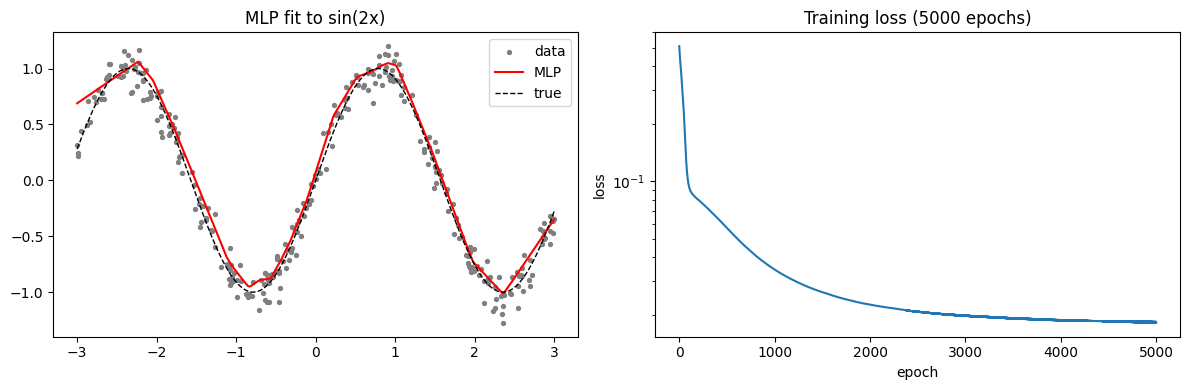

✅ multi-output: predict returns (n, 2)
✅ multi-output: R² of both targets  (0.9801 ≥ 0.95)


True

In [4]:
LR = lambda n: 1.0 / n              # workaround for the gradient-scale bug (Section 2)

X_sin = np.sort(rng.uniform(-3, 3, 300))[:, None]
y_sin = np.sin(2 * X_sin).ravel() + 0.1 * rng.normal(size=300)
# Early stopping uses an absolute tol (1e-4) and can stop while the loss still improves slowly,
# so for this smooth target we switch it off and run all epochs.
sin_net = MLPRegressor((32, 32), lr=LR(300), epochs=5000, activation="relu", random_state=SEED)
sin_net.n_iter_no_change = None
with timed("MLP (32, 32) relu on a sine, 5000 epochs"):
    sin_net.fit(X_sin, y_sin)
grid = np.linspace(-3, 3, 400)[:, None]
checks.at_least("sine: training R²", r2(y_sin, sin_net.predict(X_sin)), 0.95)
checks.check("loss_curve_ decreases overall", sin_net.loss_curve_[-1] < 0.1 * sin_net.loss_curve_[0])
checks.check("n_iter_ == len(loss_curve_)", sin_net.n_iter_ == len(sin_net.loss_curve_))
checks.check("best_loss_ tracks min(loss_curve_) to within tol",
             min(sin_net.loss_curve_) <= sin_net.best_loss_ <= min(sin_net.loss_curve_) + sin_net.tol)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(X_sin, y_sin, s=8, c="gray", label="data"); ax[0].plot(grid, sin_net.predict(grid), "r", label="MLP")
ax[0].plot(grid, np.sin(2 * grid), "k--", lw=1, label="true"); ax[0].legend(); ax[0].set_title("MLP fit to sin(2x)")
ax[1].semilogy(sin_net.loss_curve_); ax[1].set(title=f"Training loss ({sin_net.n_iter_} epochs)", xlabel="epoch", ylabel="loss")
plt.tight_layout(); plt.show()

Y2 = np.column_stack([np.sin(2 * X_sin).ravel(), np.cos(X_sin).ravel()])
multi = MLPRegressor((32, 32), lr=LR(300), epochs=4000, activation="tanh", random_state=SEED).fit(X_sin, Y2)
P2 = multi.predict(X_sin)
checks.check("multi-output: predict returns (n, 2)", P2.shape == (300, 2) and multi.n_outputs_ == 2)
checks.at_least("multi-output: R² of both targets", min(r2(Y2[:, 0], P2[:, 0]), r2(Y2[:, 1], P2[:, 1])), 0.95)

## 4. Friedman #1: MLP vs linear, activations and L2

`y = 10 sin(π x₀x₁) + 20 (x₂ − 0.5)² + 10 x₃ + 5 x₄ + noise`. Five of the ten features matter and the relationship is non-linear, so a linear model cannot capture it.

⏱️ MLP (64, 32) relu: 0.99s


⏱️ MLP (64, 32) tanh: 0.90s


⏱️ MLP (64, 32) sigmoid: 0.67s


,model,test R²,epochs
0,Ridge (linear baseline),0.7757,NaN
1,MLP relu,0.9585,971.0
2,MLP tanh,0.9732,714.0
3,MLP sigmoid,0.7773,473.0


✅ Friedman: ReLU MLP test R²  (0.9585 ≥ 0.93)
✅ Friedman: tanh MLP test R²  (0.9732 ≥ 0.93)
✅ Friedman: sigmoid MLP trains (slower, still ≈ linear)  (R² 0.777)
✅ Friedman: MLP beats the linear baseline  (0.959 vs 0.776)


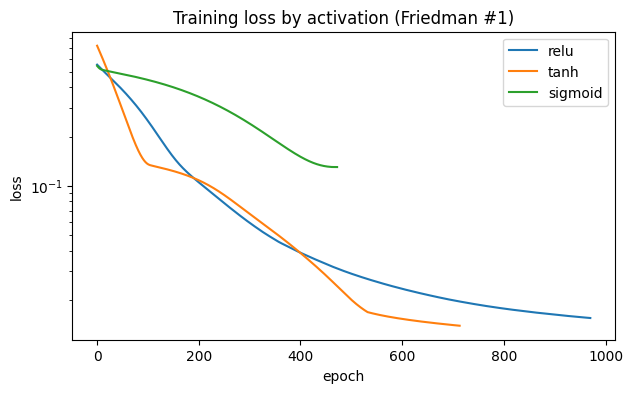

Σ‖W‖² by alpha: {0.0: 19.6, 1.0: 15.67, 10.0: 15.43}
✅ larger alpha → smaller weights (L2)


True

In [5]:
X_f, y_f = datasets.make_friedman1(n_samples=2000, noise=0.5, random_state=SEED)
Xa, Xb, ya, yb = train_test_split(X_f, y_f, test_size=0.25, random_state=SEED)
lin_r2 = r2(yb, linear_model.Ridge().fit(Xa, ya).predict(Xb))

rows = [{"model": "Ridge (linear baseline)", "test R²": lin_r2, "epochs": None}]
curves = {}
for act in ["relu", "tanh", "sigmoid"]:
    with timed(f"MLP (64, 32) {act}"):
        m = MLPRegressor((64, 32), lr=LR(len(Xa)), epochs=3000, activation=act, random_state=SEED).fit(Xa, ya)
    rows.append({"model": f"MLP {act}", "test R²": r2(yb, m.predict(Xb)), "epochs": m.n_iter_}); curves[act] = m.loss_curve_
display(pd.DataFrame(rows).round(4))
res = {r["model"]: r["test R²"] for r in rows}
checks.at_least("Friedman: ReLU MLP test R²", res["MLP relu"], 0.93)
checks.at_least("Friedman: tanh MLP test R²", res["MLP tanh"], 0.93)
checks.check("Friedman: sigmoid MLP trains (slower, still ≈ linear)", res["MLP sigmoid"] > 0.7, f"R² {res['MLP sigmoid']:.3f}")
checks.check("Friedman: MLP beats the linear baseline", res["MLP relu"] > lin_r2 + 0.1, f"{res['MLP relu']:.3f} vs {lin_r2:.3f}")

plt.figure(figsize=(7, 4))
for act, c in curves.items():
    plt.semilogy(c, label=act)
plt.title("Training loss by activation (Friedman #1)"); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.show()

norms = {}
for alpha in [0.0, 1.0, 10.0]:
    m = MLPRegressor((32,), lr=LR(len(Xa)), epochs=1500, alpha=alpha, random_state=SEED).fit(Xa, ya)
    norms[alpha] = sum(float(np.sum(l.weight ** 2)) for l in m.layers_ if isinstance(l, ModularLinearLayer))
print("Σ‖W‖² by alpha:", {k: round(v, 2) for k, v in norms.items()})
checks.check("larger alpha → smaller weights (L2)", norms[0.0] > norms[1.0] > norms[10.0])

## 5. Comparison with scikit-learn on Diabetes

Diabetes is small and noisy. A good regressor reaches a test R² of about 0.45–0.5, so any MLP should land close to the linear model and to scikit-learn's MLP.

In [6]:
X_d, y_d = datasets.load_diabetes(return_X_y=True)
Xa, Xb, ya, yb = train_test_split(X_d, y_d, test_size=0.3, random_state=SEED)
ours = MLPRegressor((16,), lr=LR(len(Xa)), epochs=2000, alpha=1.0, random_state=SEED).fit(Xa, ya)
mu, sd = Xa.mean(0), Xa.std(0)
ref = neural_network.MLPRegressor(hidden_layer_sizes=(16,), alpha=1.0, max_iter=3000, random_state=SEED).fit((Xa - mu) / sd, ya)
scores = {"ours": r2(yb, ours.predict(Xb)), "sklearn": ref.score((Xb - mu) / sd, yb),
          "ridge": r2(yb, linear_model.Ridge(alpha=1.0).fit(Xa, ya).predict(Xb))}
print({k: round(v, 4) for k, v in scores.items()})
checks.at_least("Diabetes: test R²", scores["ours"], 0.35)
checks.at_most("Diabetes: |ours − sklearn| test R²", abs(scores["ours"] - scores["sklearn"]), 0.1)

{'ours': 0.4603, 'sklearn': 0.4592, 'ridge': 0.4233}
✅ Diabetes: test R²  (0.4603 ≥ 0.35)
✅ Diabetes: |ours − sklearn| test R²  (0.0011 ≤ 0.1)


/home/mohamed-osman/.venvs/jupyter/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


True

## 6. Real data (online): Airfoil Self-Noise

NASA wind-tunnel measurements: frequency, angle of attack, chord length, velocity and boundary-layer thickness, used to predict sound pressure in dB. The relationship is strongly non-linear: a linear model gets R² ≈ 0.5 and an MLP gets about 0.9.

🌐 Airfoil Self-Noise (UCI 291): downloaded / loaded from cache


⏱️ MLP (64, 32) on 1 127 airfoils: 1.81s
test R²  MLP: 0.9041 | linear: 0.4845 | RMSE 2.14 dB
✅ Airfoil: MLP test R²  (0.9041 ≥ 0.85)
✅ Airfoil: MLP beats linear by a wide margin


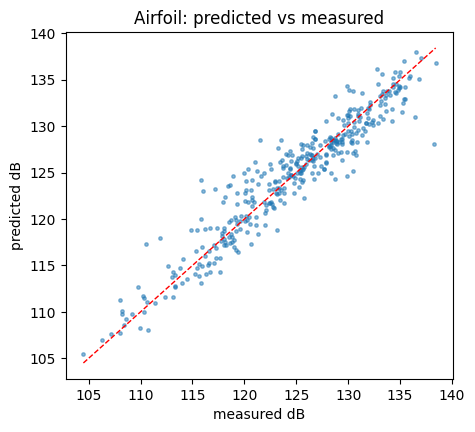

In [7]:
def _airfoil():
    from ucimlrepo import fetch_ucirepo
    d = fetch_ucirepo(id=291)
    return d.data.features.to_numpy(float), d.data.targets.to_numpy().ravel()

air, online = load_online("Airfoil Self-Noise (UCI 291)", _airfoil)
if online:
    Xr, yr = air
    Xa, Xb, ya, yb = train_test_split(Xr, yr, test_size=0.25, random_state=SEED)
    with timed("MLP (64, 32) on 1 127 airfoils"):
        am = MLPRegressor((64, 32), lr=LR(len(Xa)), epochs=4000, random_state=SEED).fit(Xa, ya)
    pa, lin_air = am.predict(Xb), r2(yb, linear_model.Ridge().fit(Xa, ya).predict(Xb))
    print(f"test R²  MLP: {r2(yb, pa):.4f} | linear: {lin_air:.4f} | RMSE {np.sqrt(np.mean((yb - pa) ** 2)):.2f} dB")
    checks.at_least("Airfoil: MLP test R²", r2(yb, pa), 0.85)
    checks.check("Airfoil: MLP beats linear by a wide margin", r2(yb, pa) > lin_air + 0.25)
    plt.figure(figsize=(5, 4.5)); plt.scatter(yb, pa, s=6, alpha=0.5); lo, hi = yb.min(), yb.max()
    plt.plot([lo, hi], [lo, hi], "r--", lw=1); plt.xlabel("measured dB"); plt.ylabel("predicted dB"); plt.title("Airfoil: predicted vs measured"); plt.show()
else:
    checks.skip("Airfoil checks", "dataset unavailable offline")

## 7. API contract and input validation

In [8]:
m = MLPRegressor((8,), epochs=5, random_state=0)
checks.check("fit() returns self", m.fit(X_sin, y_sin) is m)
checks.check("predict returns shape (n,) for a 1-D target", m.predict(X_sin).shape == (300,))
checks.check("hidden_layer_sizes may be an int", len(MLPRegressor(8, epochs=2).fit(X_sin, y_sin).layers_) == 3)
checks.check("learning_rate= alias sets lr", MLPRegressor(learning_rate=0.123).lr == 0.123)
checks.check("max_iter= / n_iterations= alias sets epochs", MLPRegressor(max_iter=7).epochs == 7 and MLPRegressor(n_iterations=9).epochs == 9)
a = MLPRegressor((8,), epochs=50, random_state=3).fit(X_sin, y_sin).predict(X_sin)
b = MLPRegressor((8,), epochs=50, random_state=3).fit(X_sin, y_sin).predict(X_sin)
checks.check("same random_state → identical predictions", np.array_equal(a, b))
no_stop = MLPRegressor((8,), lr=LR(300), epochs=200, random_state=0); no_stop.n_iter_no_change = None
checks.check("n_iter_no_change=None runs every epoch", no_stop.fit(X_sin, y_sin).n_iter_ == 200)
checks.check("targets on a large scale are handled (standardised internally)",
             r2(1e4 * y_sin, MLPRegressor((32, 32), lr=LR(300), epochs=3000, activation="relu", random_state=SEED)
                .fit(X_sin, 1e4 * y_sin).predict(X_sin)) > 0.9)
checks.raises("1-D X raises", ValueError, lambda: MLPRegressor().fit(np.arange(10.0), np.arange(10.0)))
checks.raises("NaN in X raises", ValueError, lambda: MLPRegressor().fit(np.array([[1.0], [np.nan]]), [1.0, 2.0]))
checks.raises("NaN in y raises", ValueError, lambda: MLPRegressor().fit(np.ones((2, 1)), [1.0, np.nan]))
checks.raises("X / y length mismatch raises", ValueError, lambda: MLPRegressor().fit(np.ones((3, 1)), [1.0, 2.0]))
checks.check("there is no score() method (compute R² yourself)", not hasattr(MLPRegressor(), "score"))

✅ fit() returns self
✅ predict returns shape (n,) for a 1-D target
✅ hidden_layer_sizes may be an int
✅ learning_rate= alias sets lr
✅ max_iter= / n_iterations= alias sets epochs
✅ same random_state → identical predictions
✅ n_iter_no_change=None runs every epoch


✅ targets on a large scale are handled (standardised internally)
✅ 1-D X raises  (ValueError: X must be 2-D with shape (n_samples, n_features); got a 1-D array.)
✅ NaN in X raises  (ValueError: X contains NaN or infinite values.)
✅ NaN in y raises  (ValueError: y contains NaN or infinite values.)
✅ X / y length mismatch raises  (ValueError: X and y have mismatched sample counts: X has 3, y has 2.)
✅ there is no score() method (compute R² yourself)


True

## Summary

In [9]:
checks.summary()

08 mlp: 39 passed, 0 failed, 0 skipped, 1 known bug(s) (40 checks)

Known library bugs (not counted as failures):
  🐞 fit() gradient equals the gradient of the reported loss: it is n = 200× too large (missing / n_samples), so lr effectively scales with dataset size


,check,status,detail
0,ReLU: ∂L/∂X matches finite differences (rel. e...,pass,0.0000 ≤ 1e-06
1,Tanh: ∂L/∂X matches finite differences (rel. e...,pass,0.0000 ≤ 1e-06
2,Sigmoid: ∂L/∂X matches finite differences (rel...,pass,0.0000 ≤ 1e-06
3,Softmax: ∂L/∂X matches finite differences (rel...,pass,0.0000 ≤ 1e-06
4,Linear: ∂L/∂X,pass,0.0000 ≤ 1e-06
5,Linear: ∂L/∂W,pass,0.0000 ≤ 1e-06
6,Linear: ∂L/∂b,pass,0.0000 ≤ 1e-06
7,Linear: L2 term α·W is added to ∂L/∂W,pass,0.0000 ≤ 1e-06
8,Softmax rows sum to 1 (even for large scores),pass,max |Δ| = 1.11e-16
9,"Sigmoid output in (0, 1), Tanh in (−1, 1)",pass,
